<a href="https://colab.research.google.com/github/tompickering-aur/Practice/blob/main/notebooks/03_Pandas_Amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 3 & 4 · Pandas & Transactional Data
## Amazon India: Fashion Sales Analysis

**Session objectives**
1. Load and explore a real transactional dataset with pandas
2. Clean messy data systematically and spot what AI might miss
3. Use `groupby` + aggregation to answer business questions
4. Tell a story: from data to actionable recommendation


**Options to follow along**
- Save a copy of this notebook to your own google drive or github.
- Download the notebook file, move it to a work folder, and open it through anaconda´s jupyter notebook.
- Create a new notebook with the title of the class and copy paste each cell as we go along.
---


# Note on Checking your code with AI

You are encouraged to use Gemini, ChatGPT, Claude, or similar tools. However, you should be careful to keep your coding simple to understand what AI is doing and avoid little mistakes.

Five prompting patterns that work well:

### Pattern 1 — Don't run all the code at once: run cell by cell and run your own sanity checks in between

> *See the ideas for sanity checks in all the notebooks marked with ✅*

### Pattern 2 — Show your data, ask something specific

> *I have a NumPy array called `prices` with nightly Airbnb prices. Some values are 0 (likely errors). How do I replace them with `np.nan` and compute the mean ignoring those values?*

### Pattern 3 — Specific packages and output needed

> *Could you use the panda package to combine the datasets into one dataframe*

### Pattern 4 — Ask for an explanation, not just code

> *Explain what `np.percentile(arr, 75)` does and when I would use it in a pricing analysis.*

### Pattern 5 — Ask AI to do its own sanity checks

> *Check that the sample size is still the same and include a print statement verifying the results*


### What to watch out for
- AI tools sometimes import packages they don't use (e.g., importing `re` without ever calling it)
- They may use functions we haven't covered — that's fine, but **justify the choice** in your notebook
- Don't use AI for the **ideation phase** of the Airbnb assignment — the hypothesis should be yours


## Business Context

You are a **category manager** at an Indian fashion brand selling on Amazon India. It is July 2022, end of Q2. Your data covers April–June 2022 (~120,000 orders).

First you want to investigate if revenue is growing or shrinking over Q2 and why.

Then, you have two decisions to make before Q3:

**1. Strategic:** Double down on high-volume or high-AOV?

**2. Operational:** Cancellation rates are high. What's the single most actionable fix?

**Deliverable:** A short analysis (3–4 findings) with a clear recommendation for each decision.

---

> 🧠 **Decision-first** Before you write a single line of analysis, write down your hypotheses:
>- Which categories do you *expect* to dominate revenue?
>- What do you *think* drives cancellations?
>
>Then draw potential plots that could help you answer these questions

## Coding Context: Pandas data frames

**Pandas** provides a wide range of data wrangling tools. It is typically imported as:

In [ ]:
import pandas as pd

# optional line to control formatting when tables are printed
pd.set_option('display.float_format', '{:.2f}'.format)

---
# 1. Load the data

You're working with real Amazon India Female fashion sales data from their Q2 2022 MRP which you can download [here](https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/tabular/AmazonSalesReport.csv) (click link -> open -> right-click-> save-as). This dataset provides detailed insights into Amazon sales data, including SKU, product design, category, size, pricing, and fulfillment details. It is useful for analyzing sales performance and optimizing product profitability. Before doing any analysis, you need to understand what data you're looking at:

* What does each row represent?
* What kind of columns are available?
* Are there missing values?


We can import a data file  (excel, csv, ...) using the `pd.read_x()` command where 'x' is csv, excel.

In [ ]:
# Load the Amazon India sales dataset
## locally
#df = pd.read_csv('data_raw/AmazonSalesReport.csv')

## online
df = pd.read_csv('https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/tabular/AmazonSalesReport.csv')

/tmp/ipykernel_2285/2921711430.py:6: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/tabular/AmazonSalesReport.csv')


You may be getting a warning. When pandas loads a CSV, it tries to infer the data type of each column (int, float, object, etc.). If a column has both numbers and text, pandas gets confused. Column 23 (24th column, likely 'fulfilled-by') has mixed types - probably some strings like "Easy Ship" and some missing values (NaN) or unexpected values like False.

# 2. Explore data

## 2.1 First look

First step: always **look at your data**. Before writing any analysis code, understand what you actually have.

Typically datasets come with a *data dictionary* or a *data card* like this one:

| **Variable**       | **Description**                                               | **Type**    |
|--------------------|---------------------------------------------------------------|-------------|
| `category`         | Type of product (e.g., kurta, set, top)                       | String      |
| `size`             | Size of the product                                           | String      |
| `date`             | Date of the sale                                              | Date        |
| `status`           | Status of the order (e.g., Shipped, Cancelled)                | String      |
| `fulfilment`       | Who fulfilled the order (Amazon or Merchant)                  | String      |
| `style`            | Style identifier of the product                               | String      |
| `sku`              | Stock Keeping Unit, unique product ID                         | String      |
| `asin`             | Amazon Standard Identification Number                         | String      |
| `courier_status`   | Current status of the shipping courier                        | String      |
| `qty`              | Quantity of items ordered                                     | Integer     |
| `amount`           | Sale amount per item (in INR)                                          | Float       |
| `b2b`              | Whether the customer is a business                            | Boolean     |
| `currency`         | Currency used for the transaction (usually INR)               | String      |


### Useful commands to explore the data

In [ ]:
df               # look at the whole data
df.shape         # number of rows × columns
df.index         # defaults to a RangeIndex similar to Excel row indices
df.info()        # types, null counts, memory (how much memory it is taking)
df.values        # data type defaults to `object`
df.dtypes        # but each column can have its own type
df.describe()    # min/max/mean for quantitative data — spot outliers
df.isna().sum()  # which columns have missing data?
df.head(3)       # shows the 3 first elements
df.tail(3)       # shows the 3 last elements

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126514 entries, 0 to 126513
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               126514 non-null  int64  
 1   Order ID            126514 non-null  object 
 2   Date                126514 non-null  object 
 3   Status              126514 non-null  object 
 4   Fulfilment          126514 non-null  object 
 5   Sales Channel       126514 non-null  object 
 6   ship-service-level  126514 non-null  object 
 7   Style               126514 non-null  object 
 8   base-SKU            126514 non-null  object 
 9   SKU                 126514 non-null  object 
 10  Category            126514 non-null  object 
 11  Size                126514 non-null  object 
 12  ASIN                126514 non-null  object 
 13  Courier Status      119648 non-null  object 
 14  Qty                 126514 non-null  int64  
 15  currency            118728 non-nul

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
126511,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157,J0157-DR-XXL,...,INR,690.00,HYDERABAD,TELANGANA,500049.00,IN,NaN,False,NaN,False
126512,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012,J0012-SKD-XS,...,INR,1199.00,Halol,GUJARAT,389350.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126513,128974,408-7436540-8728312,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003,J0003-SET-S,...,INR,696.00,Raipur,CHHATTISGARH,492014.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [ ]:
df.shape

(126514, 25)

`shape` returns a **tuple** — a fixed, immutable sequence (cannot be changed). You'll see it everywhere once you start working with data.

> ✅ **Sanity check:** Like ``len``, ``shape`` is extremely useful to keep track of how many rows (observations) and columns (variables) you have.

In [ ]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,126514.00,126514.00,118728.00,126481.00
mean,64474.15,0.90,661.10,464452.74
std,37243.71,0.32,268.98,191271.83
min,0.00,0.00,0.00,110001.00
25%,32171.25,1.00,458.00,382455.00
50%,64508.50,1.00,621.45,500034.00
75%,96728.75,1.00,788.00,600028.00
max,128974.00,15.00,5584.00,989898.00


>  ✅ **Sanity check:**
> How many rows does the dataset have? 126514
> Do the types look correct for every column? should we change it?
>
> Note that the data type of e.g., the fourth column, for which you would have expected `str`, is reported as `object`. Don't worry about this, you can apply string functions to this column, as will be seen later in this course.

### Exploratory graphs of the data

Let's create a very simple graph with plt to see the general trend in the data.

Behind the scenes pandas calls on other python libraries, including numpy but also matplotlib. This means that it contains a lot of convenience functions. One that we will encounter in the next classes is the ability to plot things. Those can be accessed by calling .plot on the Series or Dataframe.

To access one series/column/variable, we just use brackets after the dataframe with the name (e.g., ``df['Date']``)

<Axes: title={'center': 'Sales Amount over time'}, xlabel='Date', ylabel='Amount'>

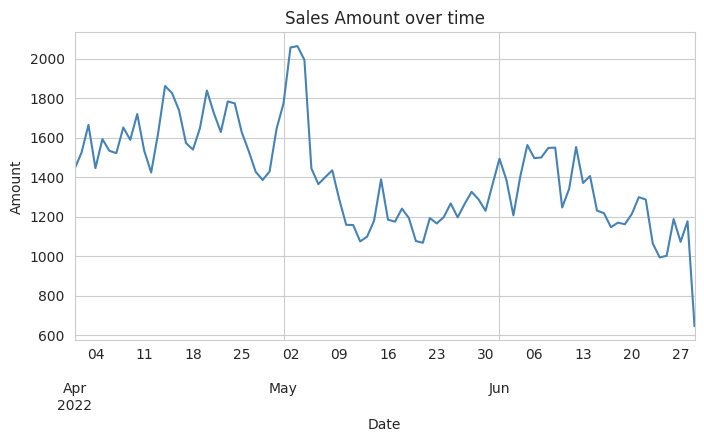

In [ ]:
# First we change the DATE column into a datetime format (we will go over this more later in the notebook)
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

# then we order the data by date with .sort (it will sort by index, other option is .sort_values()
orders_by_day = df['Date'].value_counts().sort_index()

# we plot a line graph
orders_by_day.plot.line(x='Date', y='Amount', figsize=(8, 4), color='steelblue', title="Sales Amount over time", ylabel="Amount")

In [ ]:
# to keep a better workflow, we want to add the sample size, associated notebook, and data source in the figure
sample_size = len(df['Amount']) # non-missing values for amount
notebook = str("03_Pandas_Amazon")
source = str("Amazon Sales Report 2022")

# create a formatted string with all that info
note = f"Sample size: {sample_size:,} | Data: {source} | Notebook {notebook}"
print(note)

Sample size: 126,514 | Data: Amazon Sales Report 2022 | Notebook 03_Pandas_Amazon


To add other elements to the graph and save it, we can first set the basic idea of the graph and then add each element to it.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


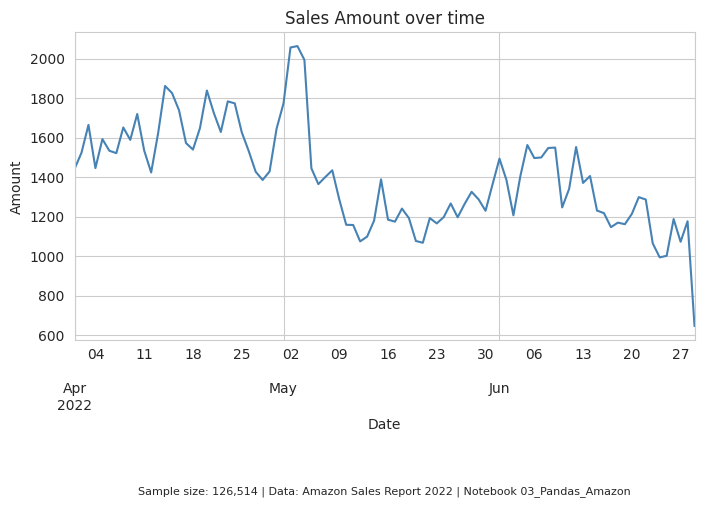

In [ ]:
#create the basic plot
ax = orders_by_day.plot.line(x='Date', y='Amount', figsize=(8, 4), color='steelblue')

# add the elements
ax.set_title("Sales Amount over time")
ax.set_ylabel("Amount")
ax.text(0.5, -0.5, note, transform=ax.transAxes, ha='center', fontsize=8)
# transform line tells python to use relative coordinates based on the plot area, not actual data values.

# save the figure locally
#ax.get_figure().savefig("outputs/orders_over_time.png", bbox_inches="tight")

# save the figure on drive
from google.colab import drive
drive.mount('/content/drive')
ax.get_figure().savefig("/content/drive/MyDrive/Colab Notebooks/outputs/orders_over_time.png", bbox_inches="tight")
# say yes to permissions

Other basic graphs options include ``df.plot.scatter`` and ``df.plot.bar``.

However, you don't *have* to stick to pandas, python has many alternative libraries like seaborn, the original matplotlib, plotly, etc.

### Looking at particular values/observations

There are two additional ways to carry out a selection:

* **Selection by label** is specified by adding `.loc` after the name of the data frame. The selection of the rows is based on the index, and that of the columns is based on the column names.
* **Selection by position** uses `.iloc`. The selection of the rows is based on the row number and that of the columns on the column number.

In both cases, if you enter a single specification inside the brackets, it refers to the rows (e.g., ``df.loc[3]``). If you enter two
specifications, the first one refers to the rows and the second one to the columns (e.g., ``df.iloc[0,1]``) .

Use `:` to select all rows or all columns.

In [ ]:
# df.loc[row_labels, column_labels]

df.loc[[0,1,2,3,4,5],['Status','Fulfilment']]

,Status,Fulfilment
0,Cancelled,Merchant
1,Shipped - Delivered to Buyer,Merchant
2,Shipped,Amazon
3,Cancelled,Merchant
4,Shipped,Amazon
5,Shipped,Amazon


In [ ]:
df.iloc[0:5,3:5]

,Status,Fulfilment
0,Cancelled,Merchant
1,Shipped - Delivered to Buyer,Merchant
2,Shipped,Amazon
3,Cancelled,Merchant
4,Shipped,Amazon


In [ ]:
# ``iloc`` makes the dataframe work like an array and indexing works similarly:
print(df.iloc[0])           # everything in the first row
#print(df.iloc[0, [3,5]])    # status and fulfilment for the first row
#print(df.iloc[:, 3])        # all the statuses
#print(df.iloc[:3])          # first 3 rows

index                                   0
Order ID              405-8078784-5731545
Date                  2022-04-30 00:00:00
Status                          Cancelled
Fulfilment                       Merchant
Sales Channel                   Amazon.in
ship-service-level               Standard
Style                              SET389
base-SKU                           SET389
SKU                        SET389-KR-NP-S
Category                              Set
Size                                    S
ASIN                           B09KXVBD7Z
Courier Status                        NaN
Qty                                     0
currency                              INR
Amount                             647.62
ship-city                          MUMBAI
ship-state                    MAHARASHTRA
ship-postal-code                400081.00
ship-country                           IN
promotion-ids                         NaN
B2B                                 False
fulfilled-by                    Ea

> ✅ **Sanity check:** Check the first 5 items to see how it looks with ``print((df.iloc[:5]))``

In [ ]:
print((df.iloc[:5]))

   index             Order ID       Date                        Status  \
0      0  405-8078784-5731545 2022-04-30                     Cancelled   
1      1  171-9198151-1101146 2022-04-30  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146 2022-04-30                       Shipped   
3      3  403-9615377-8133951 2022-04-30                     Cancelled   
4      4  407-1069790-7240320 2022-04-30                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style base-SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781   
2     Amazon      Amazon.in          Expedited  JNE3371  JNE3371   
3   Merchant      Amazon.in           Standard    J0341    J0341   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671   

               SKU  ... currency Amount    ship-city   ship-state  \
0   SET389-KR-NP-S  ...      INR 647.62       MUMBAI  MAHARASHTRA   
1  JNE37

In [ ]:
# to note, ``df[:5]`` also gives the first five items but it will depend on how the index is ordered so it is safer to use iloc.
df[:5]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.00,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,...,INR,406.00,BENGALURU,KARNATAKA,560085.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341,J0341-DR-L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.00,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671,JNE3671-TU-XXXL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.00,IN,NaN,False,NaN,NaN


**DEMO**: You can test your indexing knowledge here:
<center>
  <a href='https://claude.ai/public/artifacts/97b2f0ad-9bc7-47fb-99ab-512f71844cbc' target="_blank">
    <img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/images/demo.png'>
  </a>
</center>

### Filtering out given conditions

One of the most powerful tools in data analysis: selecting rows that satisfy a condition, called *Boolean filtering* or *Boolean masks*.

For example, let's say we want to look at what transactions were above the mean 661.10

In [ ]:
# Boolean mask — one True/False per rep
a_high = df['Amount'] >= 661.10
print(a_high)
# this gives us a boolean series (a list of true/false) which we can then apply to the whole dataframe (and only the true values will be selected)

# apply mask to the original data
df[a_high]

0         False
1         False
2         False
3          True
4         False
          ...  
126509    False
126510     True
126511     True
126512     True
126513     True
Name: Amount, Length: 126514, dtype: bool


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341,J0341-DR-L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.00,IN,NaN,False,Easy Ship,NaN
5,5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264,SET264-KR-NP-XL,...,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
10,10,407-5633625-6970741,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3160,JNE3160,JNE3160-KR-G-S,...,INR,685.00,CHENNAI,TAMIL NADU,600073.00,IN,NaN,False,NaN,NaN
14,14,408-1298370-1920302,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351,J0351-SET-L,...,INR,771.00,MUMBAI,MAHARASHTRA,400053.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
19,19,405-5957858-1051546,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET254,SET254,SET254-KR-NP-XS,...,INR,886.00,BENGALURU,KARNATAKA,560017.00,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126507,128968,403-7059995-7618722,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264,SET264-KR-NP-XL,...,INR,824.00,Delhi,DELHI,110053.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126510,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401,SET401-KR-NP-M,...,INR,999.00,GURUGRAM,HARYANA,122004.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126511,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157,J0157-DR-XXL,...,INR,690.00,HYDERABAD,TELANGANA,500049.00,IN,NaN,False,NaN,False
126512,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012,J0012-SKD-XS,...,INR,1199.00,Halol,GUJARAT,389350.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [ ]:
# boolean conditions can be cominbed e.g.,: one purchase fulfilled by merchant
one_purchase = df['Qty'] == 1
ful_merchant = df['Fulfilment'] == 'Merchant'

# the & symbol means "and", it is going to check the condition
# row-by-row for all parts of the expression and return True
# if all conditions are True

merchant_one_high = one_purchase & ful_merchant & a_high
df[merchant_one_high].head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
14,14,408-1298370-1920302,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351,J0351-SET-L,...,INR,771.00,MUMBAI,MAHARASHTRA,400053.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
32,32,404-9632124-1107550,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0011,J0011,J0011-LCD-M,...,INR,1233.00,VISAKHAPATNAM,ANDHRA PRADESH,530016.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
70,70,405-9966506-3155561,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3068,JNE3068,JNE3068-KR-A-XL,...,INR,696.00,CHENNAI,TAMIL NADU,600041.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
88,88,403-1162895-2484367,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0295,J0295,J0295-DR-XXL,...,INR,859.00,JAIPUR,RAJASTHAN,303905.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
92,92,405-1879750-2639521,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3801,JNE3801,JNE3801-KR-XXXL,...,INR,725.00,CHENNAI,TAMIL NADU,600028.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
102,102,408-7698765-2294756,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET277,SET277,SET277-KR-NP-XXL,...,INR,1338.00,AMBARNATH,MAHARASHTRA,421502.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
105,105,405-5257740-5301158,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET154,SET154,SET154-KR-NP-XL,...,INR,832.00,ROHTAK,HARYANA,124001.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
138,138,408-1482435-5202714,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET110,SET110,SET110-KR-PP-M,...,INR,788.00,CHIRMIRI,CHHATTISGARH,497449.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
146,146,171-0131752-2560336,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET355,SET355,SET355-KR-PP-M,...,INR,1399.00,BARABANKI,UTTAR PRADESH,225001.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
147,147,407-4235449-1353916,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0009,J0009,J0009-SKD-S,...,INR,999.00,AMILA,UTTAR PRADESH,275301.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN


A lot of questions in data science can be answered using complex combinations of these filters - something that gets pretty cumbersome pretty quickly in Excel ...

### Summary statistics

Use `axis=0` to compute across rows (one result per column), `axis=1` to compute across columns (one result per row):

In [ ]:
# we want the average Qty and Amount
quantitative = df.loc[:,['Qty','Amount']]

# sum for each row
print(quantitative.sum(axis=1))

0         647.62
1         407.00
2         330.00
3         753.33
4         575.00
           ...  
126509    518.00
126510   1000.00
126511    691.00
126512   1200.00
126513    697.00
Length: 126514, dtype: float64


In [ ]:
# mean across rows for Qty and Amount
print(quantitative.mean(axis=0))

# alternative way to do it
print(df['Qty'].mean())
print(df['Amount'].mean())

Qty        0.90
Amount   661.10
dtype: float64
0.9026906113157437
661.0992727073648


In [ ]:
# other useful commands
print(df['Amount'].max())
print(df['Qty'].median())
print(df['Amount'].std())

5584.0
1.0
268.9823771322954


> ✅ **Sanity check:** Does the mean, median, and standard deviation look reasonable given your data? Think of your expected range and average and if there might be any issues with the coding.

> ## ✏️  You try it Regional dynamics.
> Tasks:
> 1. Filter data for Karnataka
> 2. How many orders are placed in this state?
> 3. What is the total revenue generated? (you can use the 'Amount' column but beware it is in INR currency)
> 4. What is the average revenue per order?
> 5. Extension: draw a line plot for revenue over time in Karnataka

In [ ]:
# remember the different column names
df.info()        # types, null counts, memory (how much memory it is taking)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126514 entries, 0 to 126513
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               126514 non-null  int64         
 1   Order ID            126514 non-null  object        
 2   Date                126514 non-null  datetime64[ns]
 3   Status              126514 non-null  object        
 4   Fulfilment          126514 non-null  object        
 5   Sales Channel       126514 non-null  object        
 6   ship-service-level  126514 non-null  object        
 7   Style               126514 non-null  object        
 8   base-SKU            126514 non-null  object        
 9   SKU                 126514 non-null  object        
 10  Category            126514 non-null  object        
 11  Size                126514 non-null  object        
 12  ASIN                126514 non-null  object        
 13  Courier Status      119648 no

In [ ]:
# and here are the different states
df['ship-state'].unique()

array(['MAHARASHTRA', 'KARNATAKA', 'PUDUCHERRY', 'TAMIL NADU',
       'UTTAR PRADESH', 'CHANDIGARH', 'TELANGANA', 'ANDHRA PRADESH',
       'RAJASTHAN', 'DELHI', 'HARYANA', 'ASSAM', 'JHARKHAND',
       'CHHATTISGARH', 'ODISHA', 'KERALA', 'MADHYA PRADESH',
       'WEST BENGAL', 'NAGALAND', 'GUJARAT', 'UTTARAKHAND', 'BIHAR',
       'JAMMU & KASHMIR', 'PUNJAB', 'HIMACHAL PRADESH',
       'ARUNACHAL PRADESH', 'MANIPUR', 'GOA', 'MEGHALAYA', 'TRIPURA',
       'LADAKH', 'DADRA AND NAGAR', 'SIKKIM', nan, 'ANDAMAN & NICOBAR',
       'RAJSHTHAN', 'NL', 'MIZORAM', 'NEW DELHI',
       'PUNJAB/MOHALI/ZIRAKPUR', 'RJ', 'ORISSA', 'LAKSHADWEEP', 'PB',
       'APO', 'AR', 'PONDICHERRY', 'RAJSTHAN'], dtype=object)

In [ ]:
# filtering
# karnataka =

# Calculate the number of orders placed in this state
# total_orders = len(karnataka)

# Calculate total revenue generated
# total_revenue =

# Average revenue per order
# avg_order_value =

# Print the summary stats
# print(f"Total Orders: {total_orders}")
# print(f"Total Revenue: €{total_revenue:,.2f}")
# print(f"Average Order Value: €{avg_order_value:,.2f}")

# 3. Clean the data

Before we can trust or analyze this data, we need to clean it. That means:

* Select and drop columns
* Make naming consistent
* Fix data types
* Handle missing values
* Remove duplicates
* Create useful new columns
* Save new cleaned dataset

### Step 1: Select and drop columns we won't use

In [ ]:
df.columns  # look at names of columns

# at the end there's a weird one, likely someone added one comma too many or had a value in excel at the end of the row
# we also don't need this index

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'base-SKU', 'SKU', 'Category', 'Size',
       'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [ ]:
# To select a column (series) we can either write it in brackets with quotes
df['Unnamed: 22']

# or write it after the dot (if it doesn't have special characters)
df.index

RangeIndex(start=0, stop=126514, step=1)

In [ ]:
# we can look at info specifically for the series
df.index.name
df.index.shape

(126514,)

In [ ]:
# we create a new dataset that is equal to the old one where we drop the the columns chosen
df = df.drop(columns=['Unnamed: 22', 'index'])

## if there is an error, it might be because you already ran this command!

### Step 2: Rename columns

Let's clean up some column names, ideally in python we should not have any spaces. Let's make it all very consistent using a dictionary (remember yesterday's class!)

In [ ]:
df = df.rename(columns={
    'Order ID':           'order_id',
    'Date':               'date',
    'Status':             'status',
    'Fulfilment':         'fulfilment',
    'Sales Channel ':     'sales_channel',
    'ship-service-level': 'ship_service_level',
    'Style':              'style',
    'Category':           'category',
    'Size':               'size',
    'ASIN':               'asin',
    'Courier Status':     'courier_status',
    'Qty':                'qty',
    'currency':           'currency',
    'Amount':             'amount',
    'ship-city':          'ship_city',
    'ship-state':         'ship_state',
    'ship-postal-code':   'ship_postal_code',
    'ship-country':       'ship_country',
    'promotion-ids':      'promotion_ids',
    'B2B':                'b2b',
    'fulfilled-by':       'fulfilled_by',
})

#check
df.head(3)

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,base-SKU,SKU,category,...,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.00,IN,NaN,False,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN


> ✅ **Sanity check:** ``df.head(#)`` is an easy way to check any changes made to the dataset. However, not all columns will appear. For that you can check the length or values of ``df.columns``

In [ ]:
df.columns

Index(['order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'base-SKU', 'SKU', 'category', 'size',
       'asin', 'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by'],
      dtype='object')

### Step 3: Fix data types

Pandas has powerful tools to help you work with dates - but dates start as plain text ("strings"), which can't be analyzed or sorted properly.

So first, we **convert the `date` column** into a proper **datetime object**. Once we do that, we unlock a *lot* of cool tricks. Here's the flow:

| Concept              | What it Does                                                              |
|----------------------|---------------------------------------------------------------------------|
| `pd.to_datetime()`   | Converts text into a proper date format                                   |
| `.dt`                | A special "datetime accessor" in pandas - lets you pull out month, day, etc. |
| `.dt.month_name()` | Extracts the **month name** (e.g., "April") from a full date              |


In [ ]:
# let's first check what it looks like
print(df['date'].head())

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: date, dtype: datetime64[ns]


In [ ]:
# we already fixed it for our plot above.
# df['date'] = pd.to_datetime(df['date'], format='%m-%d-%y')

In [ ]:
print(df['date'].head())

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: date, dtype: datetime64[ns]


In [ ]:
# let's create a month variable
df['month'] = df.date.dt.month_name()

### Step 4: Handle missing values

Are there missing values?

In [ ]:
df.isna().sum()

,0
order_id,0
date,0
status,0
fulfilment,0
sales_channel,0
ship_service_level,0
style,0
base-SKU,0
SKU,0
category,0


Note that `df.isna()` is a data frame of the same shape as `df`, whose terms have type `bool`. With `sum`, we get the number of `True` values per column.

Missing values are denoted by `NaN` in Pandas. When a Pandas object is built, both plain Python’s `None` and NumPy’s `nan` are taken as NaN. Since `np.nan` has type `float`, a numeric series containing NaN values
gets type float.

Three useful Pandas methods related to missing values, which can be applied to both columns (series) and data frames, are:
* `isna` returns a Boolean mask indicating which terms are missing.
* `fillna` is used for replacing `NaN`’s by a fixed value, set by the user.
* `dropna` returns the same data frame minus the rows that contain at least one missing value. If a list of columns is specified, the missing values are searched only for those columns.

For our case, let’s apply the following business rules:

- If *amount* or *currency* is missing, drop the row (we can't use it for financial analysis).
- If *courier status* is missing, fill it with `"Unknown"`.

The rest we leave as is.

In [ ]:
df = df.dropna(subset=['amount', 'currency']).copy()
df['courier_status'] = df['courier_status'].fillna('Unknown')

### Step 5: Remove duplicates

There are two useful Pandas functions for managing duplicates:

* `drop_duplicates` drops the duplicated entries (in a series) or the duplicated rows (in a data frame).
* `duplicated` returns a Boolean series indicating which entries (for a series) or which rows (for a data
frame) are duplicated.

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
print('Before dropping duplicates:', df.shape)
df = df.drop_duplicates()
print('After dropping duplicates:', df.shape)

Before dropping duplicates: (118728, 24)
After dropping duplicates: (118725, 24)


### Step 6: Create derived columns we'll actually analyze

You can just add a new column to the dataframe by using df['new_var'] = ...

In [ ]:
# You can create whole transformations to the column and it will be applied to each individual value (like an array)
exchange_rate = 0.0118 # In 2022
df['amount_eu'] = (df['amount'] * exchange_rate).round(2)

### Step 7: Save cleaned version (always keep source data untouched)

It's good practice to save the dataframe after preprocessing. This allows you to continue with a clean dataset going forward. Make sure you specify a path that makes sense to you. When in doubt you can just use `'./data_clean/Amazon-cleaned.csv'`

In [ ]:
# Step 7:
#df.to_csv('./data_clean/Amazon-cleaned.csv', index=False)

df.to_csv('/content/drive/MyDrive/Colab Notebooks/data_clean/Amazon-cleaned.csv', index=False)

# Final sanity check — run df.info() again and check sample size
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118725 entries, 0 to 126513
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            118725 non-null  object        
 1   date                118725 non-null  datetime64[ns]
 2   status              118725 non-null  object        
 3   fulfilment          118725 non-null  object        
 4   sales_channel       118725 non-null  object        
 5   ship_service_level  118725 non-null  object        
 6   style               118725 non-null  object        
 7   base-SKU            118725 non-null  object        
 8   SKU                 118725 non-null  object        
 9   category            118725 non-null  object        
 10  size                118725 non-null  object        
 11  asin                118725 non-null  object        
 12  courier_status      118725 non-null  object        
 13  qty                 118725 non-nul

> ✅ **Sanity checks:**
> - Is `date` now `datetime64`? (it should be, not `object`)
> - Paste the output of `df.info()` into Claude and ask: *"Are there any remaining type issues or suspicious patterns I should fix before analysis?"* Then check each suggestion.

### Final Note

You don’t need to memorize all Pandas functions. You do need to keep a mental map of what’s possible. Once you know that, you can ask for help (Google, ChatGPT, docs) and get exactly what you need.

---
# 4. Analysis

**The question we're trying to answer:** Is revenue growing or shrinking over Q2, and why?

A good analysis starts with a hypothesis. Write yours here before running any code:

> *My hypothesis: revenue is [higher/lower] in [month] because...*



## 4.1 Monthly revenue trend

Figure out the meaning of `qty` and `amount_eu`, do we have a `unit_price` here? Revenue per order?

Anything weird going on otherwise with the fields?

Hint: use the `describe()` function or look at the min/max.

In [ ]:
# amount_eu is the unit price (INR amount converted to EUR)
# qty is the number of items in the order
# revenue = qty * unit_price gives total order revenue
df['revenue'] = df['qty'] * df['amount_eu']
df[['qty', 'amount_eu', 'revenue']].describe()

# “This is vectorization—no loops, just like NumPy arrays”

,qty,amount_eu,revenue
count,118725.00,118725.00,118725.00
mean,0.96,7.80,7.55
std,0.22,3.17,4.26
min,0.00,0.00,0.00
25%,1.00,5.40,5.13
50%,1.00,7.33,7.07
75%,1.00,9.30,9.30
max,8.00,65.89,527.12


the double brackets in `df[['qty', 'amount_eu', 'revenue']]` extracts a subdataframe with the series/columns specified.

To note, you can extract a subframe with a single column. Beware that this is not the same as a series.
`df['category']` is a series with shape `(118725,)`, and `df[['category']]` is a data frame with shape (118725,1)! This is a common source of confusion for people starting out in pandas.

In [ ]:
df['category'].shape
df[['category']].shape

(118725, 1)

#### Groupby

To report sales per month we need to do a `groupby()` (explained in class). This is what it looks like conceptually in our case:

#<center>
#<img src='https://github.com/tamaravdd/iese-dsmba/blob/main/notebooks/images/pandas_groupby.png?raw=1' width='100%'>
#</center>

<center>
  <img src='https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/images/pandas_groupby.png' width='50%'>
</center>


This method groups the rows according to one or more **grouping variables**. Here, you specify `groupby(by='month')`.

Next, you select the columns to be aggregated, which, here would be just `'revenue'`. Finally, you specify the **aggregation function** for example `.sum()` or `.mean`.

In [ ]:
monthly_revenue = df.groupby('month')[['revenue']].sum()
monthly_revenue

,revenue
month,
April,328611.70
June,268579.04
May,298847.94


**DEMO**: Play around with this simulation to get a feeling for how it works.

<center>
  <a href='https://claude.ai/public/artifacts/7a188c7b-8186-4188-a0cc-ec4c60e66922' target="_blank">
    <img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/images/demo.png'>
  </a>
</center>

In [ ]:
# Reorder months chronologically (groupby returns them alphabetically)
month_order = ['April', 'May', 'June']
monthly_revenue = monthly_revenue.loc[month_order]
monthly_revenue

,revenue
month,
April,328611.70
May,298847.94
June,268579.04


In [ ]:
# Calculate average revenue over last 3 months
# and how much below/above average we are
avg_q2_revenue = monthly_revenue['revenue'].mean()
avg_q2_revenue

monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)
monthly_revenue

,revenue,% below avg
month,,
April,328611.70,-10.00
May,298847.94,-0.10
June,268579.04,10.10


#### Plotting with Pandas

You can use the `.plot` within pandas to plot or use `matplotlib` and `seaborn` directly.

This is the perfect time to heavily use AI to create the perfect graph for you. Just make sure to double check what data it is using and compare to the tables you've manually created.

However, it is good to first ask yourself: what kind of visualization do I want? What do I want it to look like? AI is not the best at choosing the best plot for you.

Sample size: 126,514 | Data: Amazon Sales Report 2022 | Notebook 03_Pandas_Amazon


/tmp/ipykernel_2285/3917253289.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(list(range(0, 41, 5)))


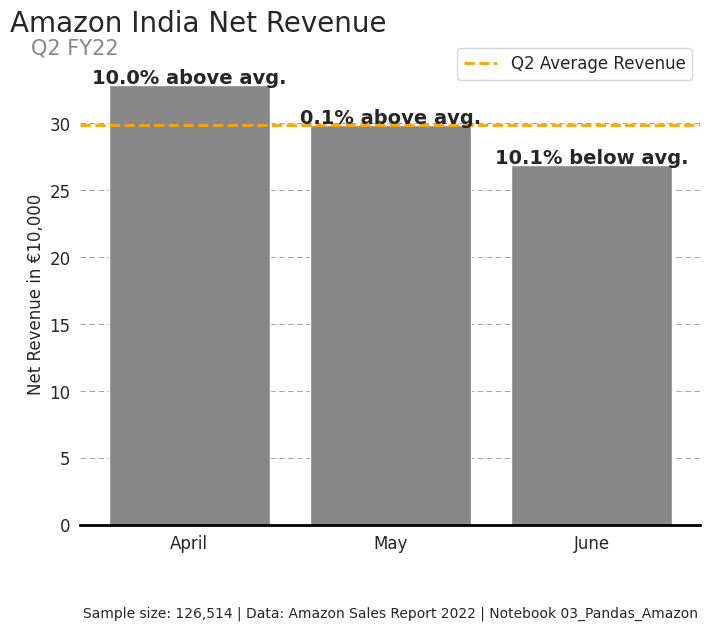

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

# Set-up data
monthly_revenue = df.groupby('month')[['revenue']].sum()

monthly_revenue = monthly_revenue.T[['April','May','June']].T
avg_q2_revenue = monthly_revenue['revenue'].mean()
monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)

# Plot bars
bars = ax.bar(monthly_revenue.index, monthly_revenue['revenue'], color='#878787')

# Add horizontal line for average
ax.axhline(avg_q2_revenue, linestyle='--', color='orange', linewidth=2, label='Q2 Average Revenue')

# Annotate each bar
for bar, pct in zip(bars, monthly_revenue['% below avg']):
    ax.annotate(f"{pct}% below avg." if pct > 0 else f"{abs(pct)}% above avg.",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height() - 7000),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=14, fontweight='bold')

# Titles and labels
ax.set_title("Amazon India Net Revenue", fontsize=20, x=0.19, y=1.05)
ax.text(-0.08, 1.02, "Q2 FY22", fontsize=15, color='#878787', transform=ax.transAxes)
ax.set_ylabel('Net Revenue in €10,000', fontsize=12, labelpad=3)
ax.set_xlabel(None)

# Ticks and grid
ax.set_yticklabels(list(range(0, 41, 5)))
ax.yaxis.grid(linestyle='--', color='gray', linewidth=0.5, dashes=(8, 5))
ax.xaxis.grid(False)
ax.tick_params(axis='both', labelsize=12)

# Spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

# add our note
print(note)
ax.text(
    0.5, -0.2,
    note,
    transform=ax.transAxes,
    ha='center',
    fontsize=10
)


plt.legend(bbox_to_anchor=(1,1.05), fontsize=12, fancybox=True)
plt.show()

#locally
# plt.savefig("outputs/amazon_revenue.png", bbox_inches='tight')


# drive
plt.savefig("/content/drive/MyDrive/Colab Notebooks/outputs/amazon_revenue.png", bbox_inches="tight")


> **Interpretation prompt:** Revenue [describe trend]. One possible explanation: *[Indian festival calendar? Seasonal fashion? Pricing?]*. To test this, we'd want to check [order count vs. average order value].

> ## ✏️ You try it:
>
> On which days is Amazon earning most of its revenue in India?
>
> 1. First create a column containing the day of the week. Hint: use `dt.day_name()` for this (day of the week) or alternatively `dt.day` (day of month).
> 2. Then, use a groupby and an aggregation function to obtain the total revenue.
> 3. BONUS: plot the result using `df.plot.bar()` or `df.plot()`
>
> You may want to produce something like this:

#<center>
#<img src='https://github.com/tamaravdd/iese-dsmba/blob/main/notebooks/images/sketch1.jpg?raw=1' width='50%'>
#</center>

<center>
  <img src='https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/images/sketch1.jpg' width='50%'>
</center>



In [ ]:
# your code here....

## 4.2 AOV and revenue

We can think of each product category as a portfolio element. High revenue = popularity. High AOV = a proxy profitability per sale. The latter is only true here because we're dealing with approximately similar margins. Plotting these gives us a clear 2x2 matrix for strategy.

#<center>
#<img src='https://github.com/tamaravdd/iese-dsmba/blob/main/notebooks/images/sketch3.jpg?raw=1' width='50%'>
#</center>

<center>
  <img src='https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/images/sketch3.jpg' width='50%'>
</center>

This lens can offer some potential strategic actions to take for the product types:
* **Underperformers**: Consider retiring or repositioning
* **Volume Drivers**: Focus on logistics, bundling, efficiency
* **Niche Upside**: Test with promos or better visibility
* **Premium Performers**: Upsell, promote, ...

In [ ]:
import matplotlib.pyplot as plt

# Calculate total revenue and AOV per category
category_metrics = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean')
).reset_index()
category_metrics

,category,total_revenue,avg_order_value
0,Blouse,5204.38,6.07
1,Bottom,1685.54,4.12
2,Dupatta,10.80,3.60
3,Ethnic Dress,8990.13,8.48
4,Saree,1484.04,9.64
5,Set,446968.24,9.72
6,Top,61811.64,6.19
7,Western Dress,126292.35,8.72
8,kurta,243591.56,5.32


### You try it

Scatter plot the total revenue v.s. median order value. The command we will use is `df.plot.scatter(x=...,y=...)`.

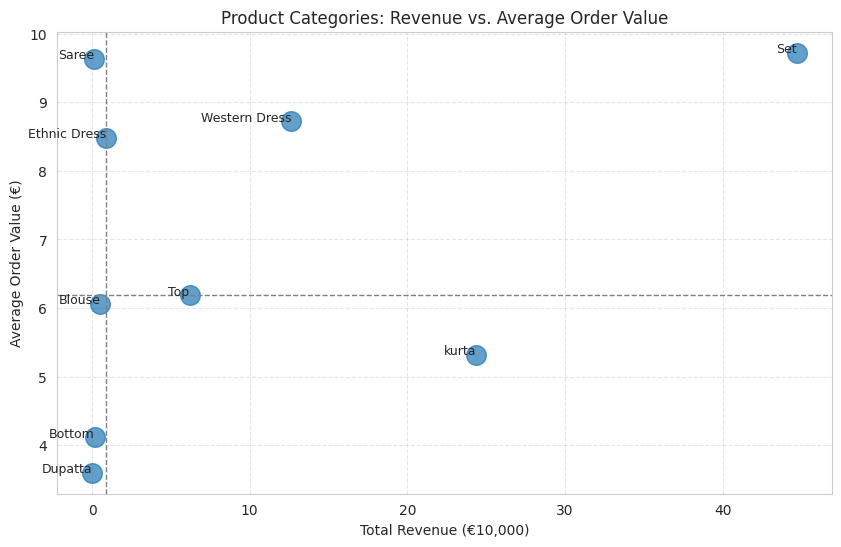

In [ ]:
category_metrics = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean'),
    median_order_value = ('revenue', 'median'),
).reset_index()
category_metrics

### Previous plot
# category_metrics.plot.scatter(
#    x='median_order_value',
#    y='total_revenue',
#    alpha=0.5,
#    color='coral'
# );

#### Fancy scatter plot
category_metrics['revenue_10k'] = category_metrics['total_revenue'] / 10000

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    category_metrics['revenue_10k'],
    category_metrics['avg_order_value'],
    s=200,
    alpha=0.7,
)

# Annotate each point with the category name
for _, row in category_metrics.iterrows():
    ax.text(row['revenue_10k'], row['avg_order_value'], row['category'], fontsize=9, ha='right')

# Add reference lines for median revenue and median AOV
median_revenue = category_metrics['revenue_10k'].median()
median_aov     = category_metrics['avg_order_value'].median()

ax.axhline(median_aov,     color='gray', linestyle='--', linewidth=1)
ax.axvline(median_revenue, color='gray', linestyle='--', linewidth=1)

# Titles and labels
ax.set(
    title='Product Categories: Revenue vs. Average Order Value',
    xlabel='Total Revenue (€10,000)',
    ylabel='Average Order Value (€)'
)
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 4.3 Cancellations & Returns

Not all orders are good news. In e-commerce, cancellations and returns create serious operational and financial issues:
* Lost revenue: These orders don't convert into sales.
* Shipping and handling costs: Often non-refundable.
* Reverse logistics: Costly and time-consuming.
* Chargebacks: Especially if customers dispute transactions.
* Fraud & abuse: Repeated returns or B2C-to-B2B loopholes.
* Money laundering flags: In some cases, abnormal return behavior is a red flag.

Long story short: cancellations and returns hurt revenue.

Let's measure the size of the problem:

* How many orders were cancelled?
* How many were returned?
* What percentage of total orders does this represent?

So far, you've used `.groupby()` for totals and averages. This time let's introduce `.value_counts()` which is a quick way to count categories in one column, like a faster `.groupby('status').shape`.

*→ This feeds Decision 2: where to focus the operational fix.*

In [ ]:
# Analyse order cancellations — find where the problem is
#
# Step 1: What % of all orders are cancelled?
#   Hint: use df['status'].value_counts() to see all statuses
#   Hint: (df['status'] == 'Cancelled').mean() gives you the rate
#
# Step 2: Does cancellation rate differ by fulfilment type?
#   Hint: df.groupby('fulfilment')['status'].apply(lambda x: (x == 'Cancelled').mean())
#   Store result in: cancel_by_fulfilment
#
# Step 3: Does cancellation rate differ by category?
#   Hint: same pattern, groupby 'category' instead
#   Store result in: cancel_by_category
#
# Step 4: Visualise — which split tells the more actionable story?
#   Hint: try a bar chart on each result

I start by thinking how I will visualize this. I'm usually not a fan of pie charts (hard to cognitively process proportions from angles), but given that we have so many barcharts on the dashboard I think it will add some visual appeal.

Maybe something like this in the Amazon colors?

#<center>
#  <img src='https://github.com/tamaravdd/iese-dsmba/blob/main/notebooks/images/sketch5.jpg?raw=1' width='50%'>
#</center>

<center>
  <img src='https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/images/sketch5.jpg' width='50%'>
</center>


Let's go!

status
Shipped                          75940
Shipped - Delivered to Buyer     28029
Cancelled                        10756
Shipped - Returned to Seller      1949
Shipped - Picked Up                945
Pending                            639
Pending - Waiting for Pick Up      272
Shipped - Returning to Seller      143
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64
=====
Cancelled Orders:        10756 (9.06%)
Returned Orders:         1949  (1.64%)


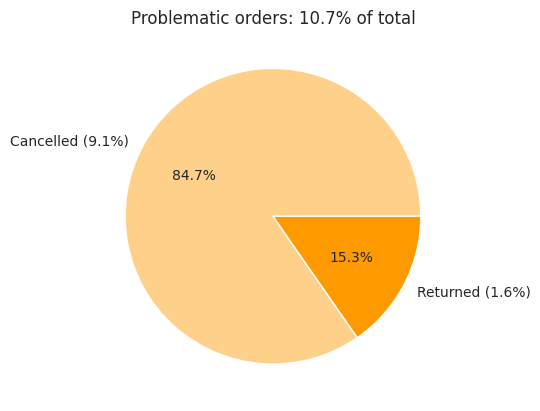

In [ ]:
# Step 1: Count all status values
print(df['status'].value_counts())

# Step 2: Filter for problematic orders (cancelled or returned)
cancelled = df[df['status'] == 'Cancelled']
returned  = df[df['status'] == 'Shipped - Returned to Seller']


# Step 3: Calculate totals and percentages
total_orders    = df.shape[0]
cancelled_pct   = len(cancelled) / total_orders * 100
returned_pct    = len(returned)  / total_orders * 100


print("=====")
print(f"Cancelled Orders:        {len(cancelled)} ({cancelled_pct:.2f}%)")
print(f"Returned Orders:         {len(returned)}  ({returned_pct:.2f}%)")

plt.pie(
    [len(cancelled), len(returned)],
    labels=[f'Cancelled ({cancelled_pct:.1f}%)', f'Returned ({returned_pct:.1f}%)'],
    colors=['#FFD08A', '#FF9900'],
    autopct='%1.1f%%'
)
plt.title(f'Problematic orders: {cancelled_pct + returned_pct:.1f}% of total')
plt.show()

> **Interpretation prompt:** High cancellation rates (churn?), high return rates (issues with quality or fit? need to figure this out to avoid expensive logistics).

---
> ## 🅰️ Your Turn — Airbnb Assignment Warm-up
>**Narrow down** your hypotheses. Look at Airbnb's data dictionary and think about what hypotheses you can actually measure for your project. **Draw graph ideas** that you would like to create in python.
>[Inside Airbnb data dictionary](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4)
>
> The same pandas skills you just used on Amazon data apply directly to your Airbnb assignment.
> Download **`listings.csv`** for your chosen city from [insideairbnb.com](http://insideairbnb.com/get-the-data/) and save it into your raw_data folder.
>
> **Load the data** and start exploring!

In [ ]:
# Load your Airbnb Data (I'm doing Chicago)
# locally
# df = pd.read_csv('data_raw/listings.csv')

# colab
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_raw/listings.csv')

# online
df = pd.read_csv('https://data.insideairbnb.com/united-states/il/chicago/2025-06-17/data/listings.csv.gz')

df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2384,https://www.airbnb.com/rooms/2384,20250617145442,2025-06-17,city scrape,Hyde Park - Walk to University of Chicago,Solo Hyde Park visitors are welcome to book th...,The apartment is less than one block from beau...,https://a0.muscache.com/pictures/hosting/Hosti...,2613,...,4.98,4.95,4.94,R17000015609,f,1,0,1,0,1.99
1,7126,https://www.airbnb.com/rooms/7126,20250617145442,2025-06-18,city scrape,Tiny Studio Apartment 94 Walk Score,A very small studio in a wonderful neighborhood.,"Ukrainian Village was just named ""Hottest Neig...",https://a0.muscache.com/pictures/51073/16c81c7...,17928,...,4.88,4.90,4.76,R24000114046,f,1,1,0,0,2.98
2,10945,https://www.airbnb.com/rooms/10945,20250617145442,2025-06-17,city scrape,The Biddle House (#1),Beautiful first floor apartment in Historic Ol...,NaN,https://a0.muscache.com/pictures/58d1a420-a24b...,33004,...,4.88,4.98,4.73,2209984,t,7,7,0,0,0.89
3,12140,https://www.airbnb.com/rooms/12140,20250617145442,2025-06-18,city scrape,Lincoln Park Guest House,Bed and Breakfast license issued by the City o...,The Guest House is in the heart of Chicago's m...,https://a0.muscache.com/pictures/miso/Hosting-...,46734,...,5.00,5.00,4.67,2398451,f,1,0,1,0,0.15
4,28749,https://www.airbnb.com/rooms/28749,20250617145442,2025-06-18,city scrape,Quirky Bucktown Loft w/ Parking No Parties,Located on a peaceful treelined street in ener...,Bucktown is a thriving community on the Northw...,https://a0.muscache.com/pictures/95884ff6-a672...,27506,...,4.88,4.93,4.72,R24000113825,f,1,1,0,0,1.43


---
## Solutions
<details>
<summary>Click to reveal: Regional Dynamics</summary>

```python
karnataka = df[df['ship_state'] == 'KARNATAKA']
total_orders = len(karnataka)
total_revenue = karnataka['amount_eu'].sum()
avg_order_value = karnataka['amount_eu'].mean()
top_category = (
    karnataka.groupby('category')['qty']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: €{total_revenue:,.2f}")
print(f"Average Order Value: €{avg_order_value:,.2f}")
print(f"Top Category: {top_category.index[0]} ({top_category.values[0]} units)")
```
</details>


<details>
<summary>Click to reveal: Day-of-week revenue</summary>

```python
import matplotlib.pyplot as plt

df['day_of_week'] = df['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = df.groupby('day_of_week')[['revenue']].sum().reindex(day_order)

revenue_by_day.plot.bar(figsize=(8, 4), color='steelblue')
plt.title('Revenue by Day of Week')
plt.xlabel('')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```
</details>

<details>
<summary>Click to reveal: Cancellation by fulfilment</summary>

```python
cancelled=('status', lambda x: (x == 'Cancelled').sum())
cancel_by_fulfilment = (
    df.groupby('fulfilment')
    .agg(total=('order_id','count'), cancelled=('is_cancelled','sum'))
    .assign(rate=lambda x: (x['cancelled']/x['total']*100).round(1))
)
```
</details>

## Additional Resources

There are many books for learning about Python, but some of them would not be appropriate for learning how to work with data in Python. It can even happen that you do not find anything about data in many of them. Mind that Python has so many applications that the intersection of the know-how of all Python users is relatively narrow. For an introduction to Python as a programming language, in a computer science context, I would recommend Zelle (2010). For the self-learning data scientist, McKinney (2017) and VanderPlas (2017) are both worth their price.

There is also plenty of learning materials in Internet, including MOOC's. For instance, **Coursera** has a pack of courses on Python (see `coursera.org/courses?query=python`). But, probably, the most attractive marketplace for data science courses is **DataCamp**. They offer, under subscription or academic license, an impressive collection of courses, most of them focused on either R or Python. In addition to follow DataCamp courses, you can also benefit from the **DataCamp Community Tutorials**, which are free and cover a wide range of topics. Finally, a good place to start is [CS dojo](https://www.youtube.com/watch?v=Z1Yd7upQsXY&list=PLBZBJbE_rGRWeh5mIBhD-hhDwSEDxogDg&index=1).

### References
This notebook is based on an original version by Miguel Ángel Canela (2022) and Enric Junqué de Fortuny (2025).